In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("../Data/Cleaned/Cleaned_Production_Data.csv")
print(f"Dataset loaded: {len(df):,} rows, {len(df.columns)} columns")
df.head()

Dataset loaded: 51,862 rows, 31 columns


,Date,Start_Hour,End_Hour,Day_of_Year,Production,Temperature_C,Humidity_Percent,Precipitation_mm,WindSpeed_kmh,Source_Wind,...,Month_Name_February,Month_Name_January,Month_Name_July,Month_Name_June,Month_Name_March,Month_Name_May,Month_Name_November,Month_Name_October,Month_Name_September,Rainfall_Flag_Yes
0,2025-11-30,21,22,334,5281,11.8,72,0.0,5.9,1,...,0,0,0,0,0,0,1,0,0,0
1,2025-11-30,18,19,334,3824,13.5,67,0.0,7.2,1,...,0,0,0,0,0,0,1,0,0,0
2,2025-11-30,16,17,334,3824,17.3,50,0.0,5.1,1,...,0,0,0,0,0,0,1,0,0,0
3,2025-11-30,23,0,334,6120,10.4,69,0.0,5.4,1,...,0,0,0,0,0,0,1,0,0,0
4,2025-11-30,6,7,334,4387,8.2,62,0.0,1.6,1,...,0,0,0,0,0,0,1,0,0,0


In [12]:
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year

df_model = df.drop(columns=["Date"])

In [13]:
feature_corr = df_model.drop(columns=["Production"]).corr(numeric_only=True).abs()

# Only look at the upper triangle to avoid duplicate pairs and self-correlation (1.0)
upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

# Stack without dropna argument (new pandas drops NaN automatically)
high_corr_pairs = upper_triangle.stack()
high_corr_pairs = high_corr_pairs[high_corr_pairs > 0.9].sort_values(ascending=False)

print(high_corr_pairs)

Series([], dtype: float64)


In [14]:
X = df_model.drop(columns=["Production"])
y = df_model["Production"]

print("Features used:", X.columns.tolist())

Features used: ['Start_Hour', 'End_Hour', 'Day_of_Year', 'Temperature_C', 'Humidity_Percent', 'Precipitation_mm', 'WindSpeed_kmh', 'Source_Wind', 'Season_Spring', 'Season_Summer', 'Season_Winter', 'Day_Name_Monday', 'Day_Name_Saturday', 'Day_Name_Sunday', 'Day_Name_Thursday', 'Day_Name_Tuesday', 'Day_Name_Wednesday', 'Month_Name_August', 'Month_Name_December', 'Month_Name_February', 'Month_Name_January', 'Month_Name_July', 'Month_Name_June', 'Month_Name_March', 'Month_Name_May', 'Month_Name_November', 'Month_Name_October', 'Month_Name_September', 'Rainfall_Flag_Yes', 'Year']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (41489, 30)
Testing set: (10373, 30)


In [16]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
print("Model trained successfully")

Model trained successfully


In [17]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance (with weather features):")
print(f"  RMSE: {rmse:.2f} MWh")
print(f"  MAE:  {mae:.2f} MWh")
print(f"  R2:   {r2:.4f}")

Linear Regression Performance (with weather features):
  RMSE: 3631.05 MWh
  MAE:  2883.90 MWh
  R2:   0.1629


**Impact of Adding Weather Features:** Compared to our original baseline (Start_Hour, Season, Month, Day of Year only), adding weather features (Temperature, Humidity, Precipitation, Wind Speed, Rainfall Flag) alongside Year improved performance across all three metrics.
R² nearly doubled, confirming that weather conditions are a meaningful driver of renewable energy production. That said, the model still only explains about 16% of the variance this is expected, since production likely depends on non-linear interactions between weather, season, and source (e.g. temperature affecting Solar and Wind output differently). This remains a useful, honest benchmark for our boosting models (XGBoost/LightGBM), which should be better equipped to capture these non-linear relationships.

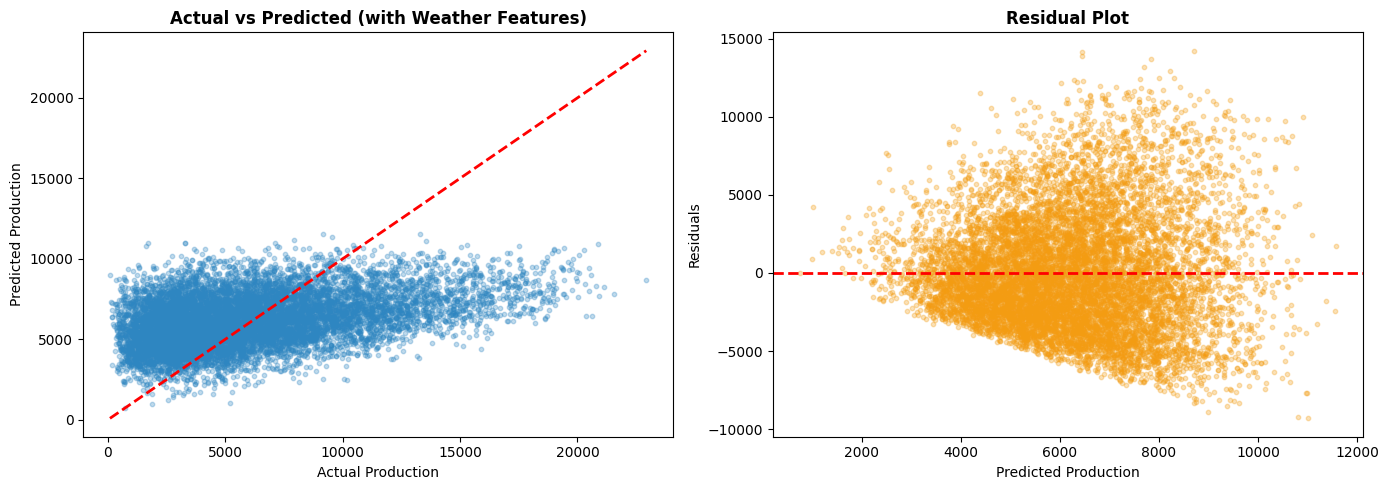

In [18]:
os.makedirs('../Visualisations/Models', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, color='#2E86C1', s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Actual Production')
axes[0].set_ylabel('Predicted Production')
axes[0].set_title('Actual vs Predicted (with Weather Features)', fontweight='bold')

residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color='#F39C12', s=10)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Production')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('../Visualisations/Models/baseline_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

**What the plots tell us:** The Actual vs. Predicted plot shows predictions clustering in a narrow horizontal band, especially failing to track the true range as Actual Production increases  the model consistently under-predicts high-production periods rather than following the red diagonal (perfect prediction) line. The Residual Plot confirms this: residuals are not randomly scattered around zero, but instead show a clear negative-sloping pattern, meaning errors get systematically more negative as predicted production increases. Together, these are classic signs of underfitting  even with weather features added, a linear model is still too simple to capture the true, non-linear relationship between our features and Production.

In [19]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("Top 10 features by coefficient magnitude:")
print(coef_df.head(10).to_string(index=False))

Top 10 features by coefficient magnitude:
             Feature  Coefficient
       Season_Winter  2701.701764
    Month_Name_March  2066.761504
Month_Name_September -2031.446237
       Season_Summer -1879.597084
      Month_Name_May -1660.384210
  Month_Name_January  1580.393587
 Month_Name_February  1554.575796
         Source_Wind  1249.312483
   Rainfall_Flag_Yes  1137.466547
     Month_Name_June -1083.994904


**Note:** Seasonal and monthly terms (Season_Winter, Month_Name_March, Month_Name_September, Season_Summer) dominate the top 10 by magnitude, consistent with our EDA's finding that Wind's winter peak and Solar's summer dip are the strongest visible seasonal patterns. Source_Wind (+1249) confirms Wind contributes more to Production than Solar. Rainfall_Flag_Yes (+1137) is a new, interesting finding  likely reflecting that rain often coincides with stronger wind systems rather than rain itself boosting output, worth exploring further.

In [20]:
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "RMSE": [rmse],
    "MAE": [mae],
    "R2": [r2]
})

results.to_csv("../Data/ModelResults/baseline_model_results.csv", index=False)
coef_df.to_csv("../Data/ModelResults/baseline_model_coefficients.csv", index=False)

print("Saved: baseline_model_results.csv")
print("Saved: baseline_model_coefficients.csv")

Saved: baseline_model_results.csv
Saved: baseline_model_coefficients.csv
